In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

rfm = pd.read_csv('../data/processed/rfm_segments.csv')

print("Rows:", rfm.shape[0])
print("Columns:", rfm.columns.tolist())

Rows: 5878
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']


In [2]:
# Use only R, F, M values as input features
features = rfm[['Recency', 'Frequency', 'Monetary']]

# Normalize so no single column dominates
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaled features shape:", scaled_features.shape)
print("First 3 rows:\n", scaled_features[:3])

Scaled features shape: (5878, 3)
First 3 rows:
 [[ 0.59558355  0.43899789  5.05805027]
 [-0.95227909  0.13150188  0.17743068]
 [-0.60353226 -0.09912012 -0.06780567]]


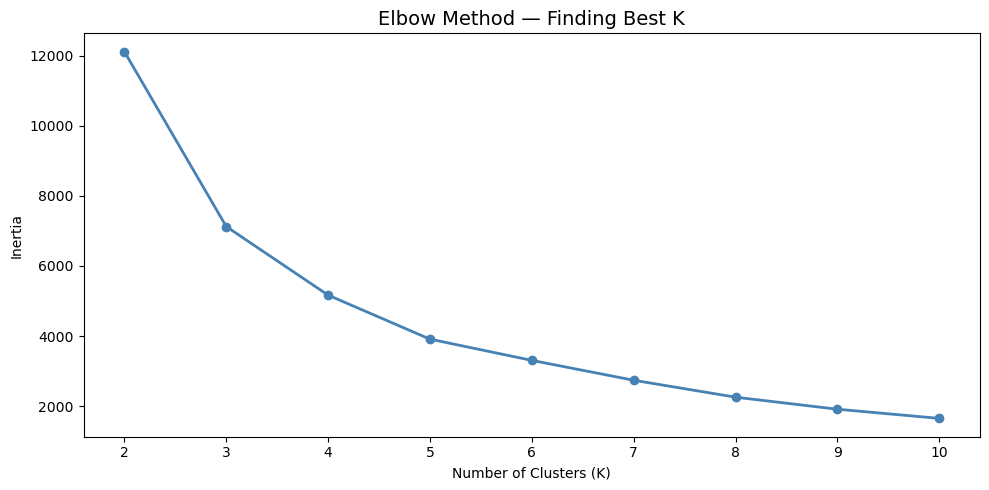

✅ Saved to outputs/chart_elbow.png

Look at the chart — find where the curve bends like an elbow.
That K value is your best number of clusters.


In [3]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Finding Best K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../outputs/chart_elbow.png')
plt.show()
print("✅ Saved to outputs/chart_elbow.png")
print("\nLook at the chart — find where the curve bends like an elbow.")
print("That K value is your best number of clusters.")

In [4]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(scaled_features)

print("Cluster counts:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0     383
1    1917
2      24
3       4
4    3550
Name: count, dtype: int64


In [5]:
cluster_profile = rfm.groupby('Cluster').agg(
    Total_Customers = ('Customer ID', 'count'),
    Avg_Recency     = ('Recency', 'mean'),
    Avg_Frequency   = ('Frequency', 'mean'),
    Avg_Monetary    = ('Monetary', 'mean')
).round(2)

print(cluster_profile)

         Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                           
0                    383        28.10          28.53      13935.16
1                   1917       471.23           2.17        755.65
2                     24        22.46         119.79     100927.04
3                      4         3.50         212.50     436835.79
4                   3550        75.71           5.12       1912.14


In [6]:
cluster_names = {
    3: 'Ultra VIP Wholesalers',
    2: 'Big Spenders',
    0: 'Loyal Regulars',
    4: 'Average Customers',
    1: 'Lost / Inactive'
}

rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

print(rfm['Cluster_Name'].value_counts())

Cluster_Name
Average Customers        3550
Lost / Inactive          1917
Loyal Regulars            383
Big Spenders               24
Ultra VIP Wholesalers       4
Name: count, dtype: int64


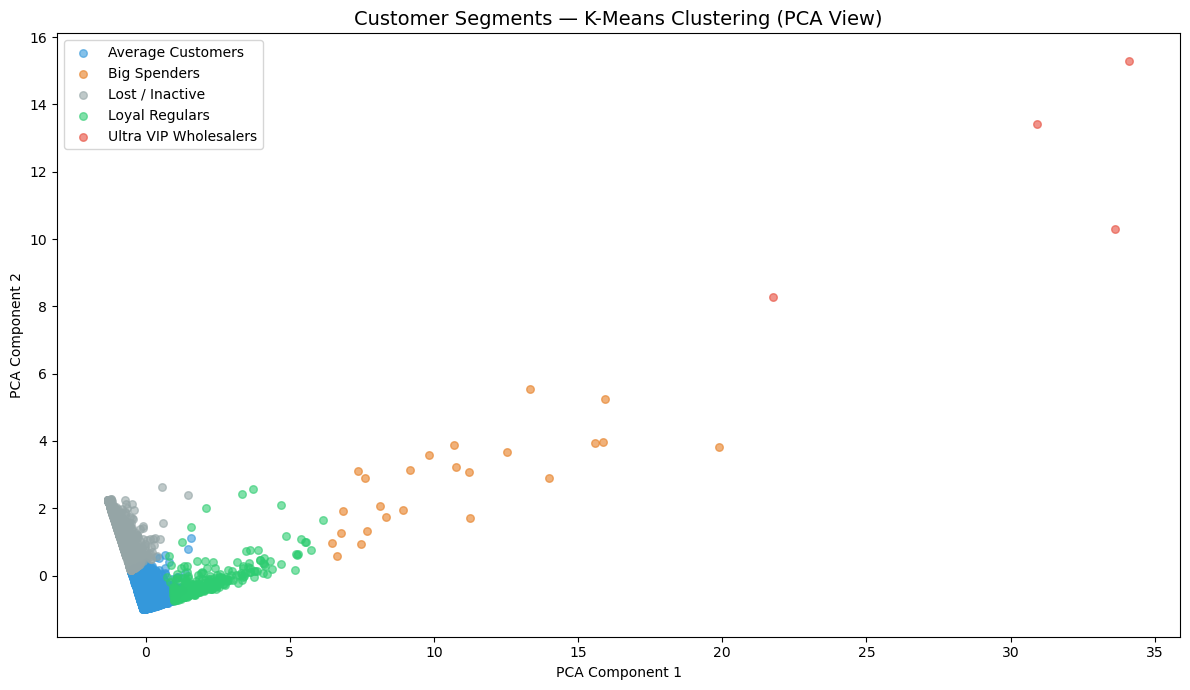

✅ Saved to outputs/chart_kmeans_clusters.png


In [7]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_features)

rfm['PCA1'] = pca_coords[:, 0]
rfm['PCA2'] = pca_coords[:, 1]

colors = {
    'Ultra VIP Wholesalers': '#e74c3c',
    'Big Spenders':          '#e67e22',
    'Loyal Regulars':        '#2ecc71',
    'Average Customers':     '#3498db',
    'Lost / Inactive':       '#95a5a6'
}

plt.figure(figsize=(12, 7))
for name, group in rfm.groupby('Cluster_Name'):
    plt.scatter(group['PCA1'], group['PCA2'],
                label=name, color=colors[name], alpha=0.6, s=30)

plt.title('Customer Segments — K-Means Clustering (PCA View)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/chart_kmeans_clusters.png')
plt.show()
print("✅ Saved to outputs/chart_kmeans_clusters.png")

In [8]:
actions = {
    'Ultra VIP Wholesalers': 'Assign a dedicated account manager. Never lose these 4 customers.',
    'Big Spenders':          'Offer exclusive deals and early access to new products.',
    'Loyal Regulars':        'Reward with loyalty program. Keep engagement high.',
    'Average Customers':     'Send targeted promotions to increase order frequency.',
    'Lost / Inactive':       'Run win-back email campaign with discount offer.'
}

print("======= BUSINESS ACTION PLAN =======\n")
for segment, action in actions.items():
    count = rfm[rfm['Cluster_Name'] == segment].shape[0]
    print(f"[{segment}] — {count} customers")
    print(f"  Action: {action}\n")

======= BUSINESS ACTION PLAN =======

[Ultra VIP Wholesalers] — 4 customers
  Action: Assign a dedicated account manager. Never lose these 4 customers.

[Big Spenders] — 24 customers
  Action: Offer exclusive deals and early access to new products.

[Loyal Regulars] — 383 customers
  Action: Reward with loyalty program. Keep engagement high.

[Average Customers] — 3550 customers
  Action: Send targeted promotions to increase order frequency.

[Lost / Inactive] — 1917 customers
  Action: Run win-back email campaign with discount offer.



In [9]:
rfm.to_csv('../data/processed/customer_segments.csv', index=False)

print("✅ Saved to data/processed/customer_segments.csv")

✅ Saved to data/processed/customer_segments.csv
